In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
root_dir = Path("../../../class.vision/")

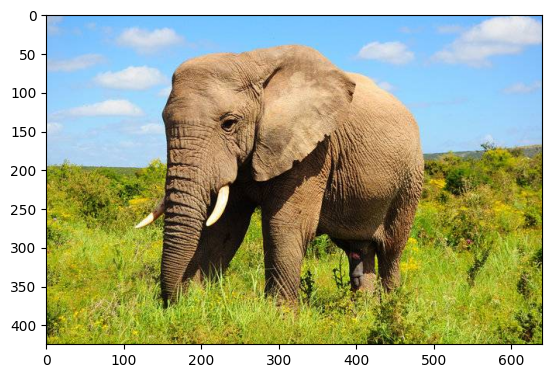

In [3]:
image = cv.imread(root_dir / "images/elephant.jpg")
plt.imshow(image[...,::-1]);

In [4]:
with open(root_dir / "model/caffe/synset_words.txt") as f:
    classes = []
    for line in f.readlines():
        classes.append(line[line.find(" ") + 1:].split(",")[0].strip())

print("len:",len(classes), "| last class:", classes[-1])

len: 1000 | last class: toilet tissue


In [5]:
def img_blob(image):
    blob = cv.dnn.blobFromImage(image, 1, (224, 224), (104, 117, 123))
    print("blob.shape:", blob.shape)
    return blob

blob.shape: (1, 3, 224, 224)


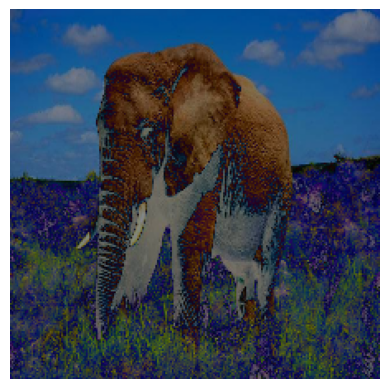

In [6]:
blob = img_blob(image)
# Display blob
img = cv.convertScaleAbs(blob[0].transpose(1, 2, 0))
plt.imshow(img[..., ::-1]); plt.axis('off');

In [7]:
net = cv.dnn.readNetFromCaffe(root_dir/"model/caffe/bvlc_googlenet.prototxt", root_dir/"model/caffe/bvlc_googlenet.caffemodel")

In [8]:
net.setInput(blob)
preds = net.forward()

In [9]:
top3idx = np.argsort(preds[0])[-3:][::-1]
for idx in top3idx:
    print("class:", classes[idx], f"{preds[0][idx]:.2f}%")

class: African elephant 0.83%
class: tusker 0.14%
class: Indian elephant 0.04%
